# Projeto Introdução à Aprendizagem Automática
**Grupo: AO**

**Membros:**
* Rafael Matias - 61847
* Diogo Vasconcelos - 61809
* João Nunes - 61786

**Contribuições:**
* Rafael Matias: 33% Tarefas: Análise dos dados dos passageiros (distribuição da variavel Transported), Objetivo 1, Objetivo 4 
* Diogo Vasconcelos: 33% Tarefas: Objetivo 2, Objetivo 4
* João Nunes: Tarefas: 33% Tarefas: Objetivo 3, Objetivo 4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer


import warnings
warnings.filterwarnings('ignore')

In [2]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.7/101.7 MB 19.9 MB/s eta 0:00:05
   ----- ---------------------------------- 14.4/101.7 MB 37.9 MB/s eta 0:00:03
   ------------- -------------------------- 33.6/101.7 MB 60.6 MB/s eta 0:00:02
   ----------------- ---------------------- 44.0/101.7 MB 56.0 MB/s eta 0:00:02
   -------------------------- ------------- 66.8/101.7 MB 67.7 MB/s eta 0:00:01
   ---------------------------------- ----- 87.0/101.7 MB 73.2 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 75.6 MB/s eta 0:00:01
   --------------------------------------- 101.7/101.7 MB 70.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## Introdução e Análise Exploratória de Dados (EDA)
O objetivo deste projeto é analisar os dados dos passageiros do Spaceship Titanic e resolver três problemas preditivos e um de análise de atributos. Durante o voo, uma anomalia transportou metade dos passageiros para outra dimensão.

Dimensão do dataset: (6954, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,4066_02,Europa,True,B/155/S,TRAPPIST-1e,22.0,False,0.0,0.0,0.0,0.0,0.0,Diramak Objeciane,True
1,8602_01,Earth,True,G/1396/P,TRAPPIST-1e,3.0,False,0.0,0.0,0.0,0.0,0.0,Robina Weissey,False
2,4181_06,Europa,False,C/133/P,55 Cancri e,41.0,True,0.0,9463.0,0.0,1022.0,1562.0,Ranan Frattyring,True
3,8112_01,Earth,False,F/1553/S,PSO J318.5-22,23.0,False,90.0,4.0,0.0,7.0,588.0,Benda Dickley,False
4,3152_01,Earth,True,G/496/S,TRAPPIST-1e,14.0,False,0.0,0.0,0.0,0.0,0.0,Therek Greeves,False


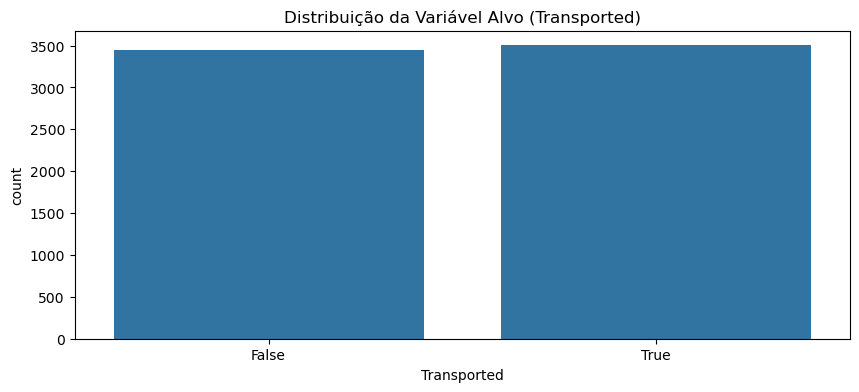

PassengerId       0
HomePlanet      158
CryoSleep       162
Cabin           161
Destination     147
Age             148
VIP             169
RoomService     135
FoodCourt       148
ShoppingMall    170
Spa             145
VRDeck          145
Name            170
Transported       0
dtype: int64


In [3]:

df = pd.read_csv('spaceship_data.csv')

print("Dimensão do dataset:", df.shape)
display(df.head())


plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Transported')
plt.title("Distribuição da Variável Alvo (Transported)")
plt.show()


print(df.isnull().sum())

## Descrição do Pré-processamento
Para preparar os dados para os modelos:
* **Tratamento de Nulos:** As variáveis numéricas (como `Age`, `FoodCourt`, `ShoppingMall`) foram preenchidas com a mediana. Variáveis categóricas (`HomePlanet`, `Destination`) com o valor mais frequente (moda).
* **Encoding:** Variáveis categóricas foram transformadas usando `LabelEncoder`.
* **Scaling:** Foi aplicado `StandardScaler` aos atributos numéricos para garantir estabilidade em modelos como a Regressão Logística/Linear.

In [4]:
def preprocess_data(data, is_train=True, encoders=None, scaler=None):
    df_proc = data.copy()
    
    
    if 'Cabin' in df_proc.columns:
        df_proc[['Deck', 'Num', 'Side']] = df_proc['Cabin'].str.split('/', expand=True)
        df_proc.drop('Cabin', axis=1, inplace=True)
        
    
    
    num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
    
    for col in num_cols:
        if col in df_proc.columns:
           
            df_proc[col] = df_proc[col].fillna(df_proc[col].median())
            
    for col in cat_cols:
        if col in df_proc.columns:
            
            df_proc[col] = df_proc[col].fillna(df_proc[col].mode()[0])
            
  
    cols_to_drop = ['PassengerId', 'Name', 'Num']
    df_proc.drop(columns=[c for c in cols_to_drop if c in df_proc.columns], inplace=True)
    
  
    if is_train:
        encoders = {}
        for col in cat_cols:
            if col in df_proc.columns:
                le = LabelEncoder()
                df_proc[col] = le.fit_transform(df_proc[col].astype(str))
                encoders[col] = le
                
        
        
        features_to_scale = [c for c in num_cols if c in df_proc.columns and c != 'FoodCourt' and c != 'Age']
        
        scaler = StandardScaler()
        if features_to_scale:
            df_proc[features_to_scale] = scaler.fit_transform(df_proc[features_to_scale])
            
        return df_proc, encoders, scaler
    else:
        for col in cat_cols:
            if col in df_proc.columns:
                df_proc[col] = df_proc[col].map(lambda s: '<unknown>' if s not in encoders[col].classes_ else s)
                encoders[col].classes_ = np.append(encoders[col].classes_, '<unknown>')
                df_proc[col] = encoders[col].transform(df_proc[col].astype(str))
        
        features_to_scale = [c for c in num_cols if c in df_proc.columns and c != 'FoodCourt' and c != 'Age']
        if features_to_scale:
            df_proc[features_to_scale] = scaler.transform(df_proc[features_to_scale])
        return df_proc


df_clean, encoders, scaler = preprocess_data(df)

## Objetivo 01: Prever a variável Transported
* **Métrica:** Accuracy e F1-Score.
* **Modelos (Máximo 3):** Regressão Logística, Random Forest e XGBoost.

In [17]:
# Features e alvo
X_1 = df_clean.drop('Transported', axis=1)
y_1 = df_clean['Transported'].astype(int)

# 1. Regressão Logística
lr = LogisticRegression(max_iter=1000)
lr.fit(X_1, y_1)

# 2. Random Forest
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3
)
grid_rf.fit(X_1, y_1)
best_rf_1 = grid_rf.best_estimator_

# 3. XGBoost
from xgboost import XGBClassifier
xgb = XGBClassifier(
   n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_1, y_1)

# Carregar conjunto externo
space_ex_o1 = pd.read_csv("space_ex_o1.csv")
space_ex_o1_y = pd.read_csv("space_ex_o1_y.csv")

# Aplicar mesmo pré-processamento
space_ex_o1_proc = preprocess_data(
    space_ex_o1,
    is_train=False,
    encoders=encoders,
    scaler=scaler
)

# Garantir mesmas colunas
space_ex_o1_proc = space_ex_o1_proc.reindex(
    columns=X_1.columns,
    fill_value=0
)

# Previsões
preds_lr_ex = lr.predict(space_ex_o1_proc)
preds_rf_ex = best_rf_1.predict(space_ex_o1_proc)
preds_xgb_ex = xgb.predict(space_ex_o1_proc)

# Valores reais
y_true_ex_o1 = space_ex_o1_y['Transported'].astype(int)

# Tabela comparativa
res_obj1 = pd.DataFrame({
    'Modelo': [
        'Regressão Logística',
        'Random Forest (Tuned)',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_true_ex_o1, preds_lr_ex),
        accuracy_score(y_true_ex_o1, preds_rf_ex),
        accuracy_score(y_true_ex_o1, preds_xgb_ex)
    ],
    'F1-Score': [
        f1_score(y_true_ex_o1, preds_lr_ex),
        f1_score(y_true_ex_o1, preds_rf_ex),
        f1_score(y_true_ex_o1, preds_xgb_ex)
    ]
})

display(res_obj1)

,Modelo,Accuracy,F1-Score
0,Regressão Logística,0.8,0.888889
1,Random Forest (Tuned),0.8,0.888889
2,XGBoost,0.7,0.769231


**Seleção de variáveis, justificação para métricas e avaliação**

Foram utilizadas como variáveis de entrada todos os atributos disponíveis após o pré-processamento dos dados.

Por se tratar de um problema de classificação binária supervisionada, foram utilizadas as métricas Accuracy e F1-Score para avaliar o desempenho dos modelos.

A métrica Accuracy mede a proporção total de previsões corretas realizadas pelo modelo.

Já o F1-Score representa a média harmónica entre precisão e recall, sendo particularmente útil para avaliar o equilíbrio entre falsos positivos e falsos negativos.

Foram testados três modelos de classificação supervisionada: Regressão Logística, Random Forest e XGBoost.

**Resultados dos modelos**

Os resultados obtidos demonstram que a Regressão Logística e o Random Forest Regressor apresentaram o melhor desempenho no conjunto de teste externo, obtendo valores idênticos de Accuracy e F1-Score.

O modelo XGBoost apresentou desempenho inferior relativamente aos restantes modelos, sugerindo possível overfitting ou menor capacidade de generalização no conjunto de teste utilizado.

Os resultados finais encontram-se resumidos na tabela seguinte.

**Caracterização do tuning de hiper-parâmetros**

Para o modelo Random Forest foi realizado tuning de hiper-parâmetros utilizando GridSearchCV com validação cruzada de 3 folds (cv=3).

Foram testados diferentes valores para:

* n_estimators: número de árvores da floresta;
* max_depth: profundidade máxima das árvores.

O objetivo deste processo foi encontrar automaticamente a combinação de hiper-parâmetros que produzisse melhor desempenho no problema de classificação.

No modelo XGBoost foram ajustados manualmente parâmetros como o número de árvores (n_estimators), profundidade máxima das árvores (max_depth), learning_rate e parâmetros de subsampling, procurando melhorar a capacidade de generalização do modelo.

**Conclusão** 

Os resultados obtidos demonstram que modelos relativamente simples conseguem apresentar elevado desempenho na previsão da variável Transported após um pré-processamento adequado dos dados.

A Regressão Logística apresentou desempenho equivalente ao Random Forest no conjunto de teste externo, sugerindo que as relações entre os atributos e a variável alvo são suficientemente capturadas por um modelo linear.

Apesar de o XGBoost ser um modelo mais complexo e frequentemente muito eficaz em problemas tabulares, neste caso apresentou menor capacidade de generalização relativamente aos restantes modelos.


## Objetivo 02: Prever o valor dispendido (FoodCourt)
* **Métrica:** RMSE (Root Mean Squared Error) e MAE (Mean Absolute Error), visto ser um problema de regressão.
* **Modelos:** Regressão Linear Múltipla, Random Forest Regressor.

In [6]:
# Garantir que isolamos corretamente as features (X) e o alvo limpo (y)
X_2 = df_clean.drop(['FoodCourt', 'Transported'], axis=1, errors='ignore')
y_2 = np.log1p(df_clean['FoodCourt']) # Já está preenchido e sem nulos devido ao novo pré-processamento

# 1. Regressão Linear
lin_reg = LinearRegression()
lin_reg.fit(X_2, y_2)

# 2. Random Forest Regressor com Tuning
param_grid_rfr = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10,]
}
grid_rfr = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rfr,
    cv=3,
    scoring='neg_mean_squared_error'
)
grid_rfr.fit(X_2, y_2)

best_rfr_2 = grid_rfr.best_estimator_

# Carregar conjunto de exemplo
space_ex_o2 = pd.read_csv("space_ex_o2.csv")
space_ex_o2_y = pd.read_csv("space_ex_o2_y.csv")

# Aplicar o mesmo pré-processamento
space_ex_o2_proc = preprocess_data(space_ex_o2, is_train=False, encoders=encoders, scaler=scaler)

# Garantir mesmas colunas do treino
space_ex_o2_proc = space_ex_o2_proc.reindex(columns=X_2.columns, fill_value=0)

# Previsões do random forest regressor
preds_ex_o2 = np.expm1(best_rfr_2.predict(space_ex_o2_proc))

# Previsões da regressão linear
preds_lin_ex = np.expm1(lin_reg.predict(space_ex_o2_proc))

# Selecionar apenas a coluna correta
y_true_ex_o2 = space_ex_o2_y['FoodCourt']

# Métricas RF
rmse_ex_o2 = np.sqrt(mean_squared_error(y_true_ex_o2, preds_ex_o2))
mae_ex_o2 = mean_absolute_error(y_true_ex_o2, preds_ex_o2)

# Métricas Linear
rmse_lin_ex = np.sqrt(mean_squared_error(y_true_ex_o2, preds_lin_ex))
mae_lin_ex = mean_absolute_error(y_true_ex_o2, preds_lin_ex)

# Tabela comparativa
res_obj2 = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest Regressor'],
    'RMSE': [rmse_lin_ex, rmse_ex_o2],
    'MAE': [mae_lin_ex, mae_ex_o2]
})

display(res_obj2)

,Modelo,RMSE,MAE
0,Regressão Linear,330.279477,126.525608
1,Random Forest Regressor,329.968029,125.700000


RMSE: 329.96802875430217
MAE: 125.7


Inicialmente foi realizado um pré-processamento ao dataset de forma a preparar os dados para os modelos de Machine Learning.

Os valores em falta foram tratados através de preenchimento adequado, garantindo que não existiam valores NaN nas variáveis utilizadas pelos modelos. As variáveis categóricas foram convertidas para formato numérico utilizando one-hot encoding através da função preprocess_data().

Foi removida a variável alvo Transported do conjunto de features (X), mantendo apenas os atributos relevantes para a previsão da variável FoodCourt.

Adicionalmente, foi aplicada uma transformação logarítmica à variável alvo FoodCourt utilizando np.log1p(), com o objetivo de reduzir a assimetria da distribuição e diminuir o impacto de outliers nos modelos.

Foram utilizadas como variáveis de entrada todos os atributos disponíveis após o pré-processamento, excluindo apenas as variáveis FoodCourt e Transported.

Por se tratar de um problema de regressão supervisionada, foram utilizadas as métricas RMSE (Root Mean Squared Error) e MAE (Mean Absolute Error).

O RMSE penaliza mais fortemente erros elevados, sendo particularmente útil para avaliar a precisão global das previsões.

O MAE mede o erro absoluto médio das previsões, sendo mais interpretável relativamente à magnitude média do erro.

Foram testados os modelos Regressão Linear Múltipla e Random Forest Regressor.

Para o modelo Random Forest Regressor foi realizado tuning de hiper-parâmetros utilizando GridSearchCV com validação cruzada de 3 folds (cv=3). Foram testados diferentes valores para o número de árvores da floresta (n_estimators) e profundidade máxima das árvores (max_depth), permitindo selecionar automaticamente a combinação de parâmetros com melhor desempenho.

Após o treino dos modelos, foram realizadas previsões no conjunto de exemplo fornecido no enunciado (space_ex_o2.csv), sendo os resultados comparados com os valores reais presentes em space_ex_o2_y.csv.

Os resultados obtidos demonstram que a transformação logarítmica aplicada à variável alvo teve um impacto significativo no desempenho dos modelos. Embora o Random Forest Regressor tenha inicialmente apresentado resultados superiores, a Regressão Linear revelou desempenho semelhante após o pré-processamento dos dados, obtendo valores próximos de RMSE e MAE.

Isto sugere que, após a redução da assimetria da variável FoodCourt, as relações entre as variáveis se tornaram mais próximas de um comportamento linear, favorecendo modelos mais simples e interpretáveis.

## Objetivo 03: Prever a Idade (Age) dos passageiros transportados
Neste objetivo pretende-se avaliar até que ponto é possível prever com confiança a idade dos passageiros. Uma vez que a idade é uma variável numérica, será utilizada uma abordagem de regressão.

A análise será realizada apenas sobre passageiros transportados (`Transported=True`).


### Nota sobre o target

Neste objetivo não serão utilizadas linhas onde a idade original é desconhecida, evitando treinar os modelos com valores preenchidos artificialmente na variável que se pretende prever. Caso contrário, o modelo poderia aprender padrões a partir de idades que não correspondem a valores reais.

### Seleção de variáveis, métricas e avaliação
Neste objetivo foram utilizados os dados após o pré-processamento anteriormente realizado, incluindo o tratamento de valores em falta, encoding das variáveis categóricas e normalização das variáveis numéricas.

Como variável alvo foi utilizada `Age`, sendo removida das features juntamente com `Transported`, uma vez que essa variável é utilizada apenas como filtro para os passageiros considerados neste objetivo.

Foram testados três modelos de regressão: **Regressão Linear**, **Decision Tree Regressor** e **Random Forest Regressor**.
* **Linear Regression** - foi utilizada como abordagem inicial por se tratar de um problema de previsão de um valor numérico contínuo, permitindo obter uma baseline simples para comparação.
* **Decision Tree Regressor** - foi utilizada por ser capaz de capturar relações menos lineares entre as variáveis e identificar padrões através de divisões sucessivas dos dados.
* **Random Forest Regressor** - foi utilizada como abordagem final por ser capaz de melhorar os resultados através da combinação de múltiplas árvores de decisão, tornando o modelo mais robusto e menos dependente de padrões específicos dos dados de treino.

Para avaliar o desempenho dos modelos foram utilizadas as métricas **MAE**, **RMSE** e **R²**.
* **MAE (Mean Absolute Error)** - permite observar o erro médio absoluto das previsões, ou seja, é útil para perceber quantos anos o modelo se afasta da idade real.
* **RMSE (Root Mean Squared Error)** - foi utilizado por penalizar mais previsões com erros elevados, complementando a análise do erro médio do modelo.
* **R²** - foi utilizado para perceber até que ponto o modelo consegue prever melhor do que simplesmente assumir a idade média dos passageiros, permitindo comparar o desempenho dos diferentes modelos.


In [7]:
# Nova coluna para determinar gasto total
df_clean["TotalSpent"] = (df_clean["RoomService"] + df_clean["FoodCourt"] + df_clean["ShoppingMall"] + df_clean["Spa"] + df_clean["VRDeck"])

#selecionar apenas os passageiros transportados e com idade disponível
valid_passengers_idx = df[(df["Transported"] == True) & (df["Age"].notna())].index
df_o3 = df_clean.loc[valid_passengers_idx].copy()

#Definir target - apenas com idades reais
y_3 = df.loc[valid_passengers_idx, "Age"]

#Definir features - sem filtro (Transported) e target (Age)
X_3 = df_o3.drop(["Age", "Transported"], axis=1, errors="ignore")

X_train_3, X_val_3, y_train_3, y_val_3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

#Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_3, y_train_3)
preds_lin = lin_reg.predict(X_val_3)

mae_lin = mean_absolute_error(y_val_3, preds_lin)
rmse_lin = np.sqrt(mean_squared_error(y_val_3, preds_lin))
r2_lin = r2_score(y_val_3, preds_lin)

# Decision tree com GridSearch para testar hiperparâmetros
param_grid_dtr = {"max_depth": [3, 5, 10, None], "min_samples_leaf": [1, 5, 10]}
grid_dtr = GridSearchCV( DecisionTreeRegressor(random_state=42), param_grid_dtr, cv=3, scoring="neg_mean_squared_error")
grid_dtr.fit(X_train_3, y_train_3)
preds_dtr  = grid_dtr.predict(X_val_3)

mae_dtr = mean_absolute_error(y_val_3, preds_dtr)
rmse_dtr = np.sqrt(mean_squared_error(y_val_3, preds_dtr))
r2_dtr = r2_score(y_val_3, preds_dtr)

# Random forest com GridSearch para testar hiperparâmetros
param_grid_rfr = {"n_estimators": [50, 100, 200], "max_depth": [5, 10, 15, None], "min_samples_leaf": [1, 3, 5], "max_features": ["sqrt", None]}
grid_rfr = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rfr, cv=3, scoring="neg_mean_squared_error")
grid_rfr.fit(X_train_3, y_train_3)
preds_rfr = grid_rfr.predict(X_val_3)

mae_rfr = mean_absolute_error(y_val_3, preds_rfr)
rmse_rfr = np.sqrt(mean_squared_error(y_val_3, preds_rfr))
r2_rfr = r2_score(y_val_3, preds_rfr)

# Tabela de Resultados
res_obj3 = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Decision Tree','Random Forest'],
    'MAE': [mae_lin, mae_dtr, mae_rfr],
    'RMSE': [rmse_lin, rmse_dtr, rmse_rfr],
    'R²': [r2_lin, r2_dtr, r2_rfr]
})

### Caracterização do tuning de hiper-parâmetros
Nos modelos baseados em árvores foi utilizado `GridSearchCV` com validação cruzada (`cv=3`), permitindo testar automaticamente diferentes combinações de hiper-parâmetros e selecionar a que apresentou melhor desempenho médio.

No modelo **Decision Tree Regressor** foram testados diferentes valores de `max_depth`, que controla a profundidade máxima da árvore, e `min_samples_leaf`, que define o número mínimo de exemplos numa folha final.

No modelo **Random Forest Regressor** foram ainda testados diferentes números de árvores (`n_estimators`) e o número de variáveis consideradas em cada divisão (`max_features`), bem como diferentes profundidades máximas e tamanhos mínimos de folha.

A validação cruzada permitiu avaliar cada combinação de hiper-parâmetros em diferentes subconjuntos dos dados, permitindo avaliar cada combinação em diferentes subconjuntos dos dados e reduzindo o risco de selecionar hiper-parâmetros demasiado ajustados ao conjunto de treino.





In [8]:
best_params_obj3 = pd.DataFrame([
    {"Modelo": "Decision Tree", **grid_dtr.best_params_},
    {"Modelo": "Random Forest", **grid_rfr.best_params_}
])

display(best_params_obj3.fillna("-"))

,Modelo,max_depth,min_samples_leaf,max_features,n_estimators
0,Decision Tree,3,1,-,-
1,Random Forest,5,1,-,200.0


### Resultados dos Modelos


In [9]:
display(res_obj3)

,Modelo,MAE,RMSE,R²
0,Regressão Linear,11.874515,14.893393,0.053199
1,Decision Tree,11.070763,14.067316,0.155317
2,Random Forest,10.911725,13.868636,0.179008


### Previsão no conjunto de exemplo fornecido


In [10]:
# Carregar conjunto de exemplo
space_ex_o3 = pd.read_csv("space_ex_o3.csv")
space_ex_o3_y = pd.read_csv("space_ex_o3_y.csv")

#selecionar apenas os passageiros transportados
valid_passengers_idx = space_ex_o3[space_ex_o3["Transported"] == True].index
space_ex_o3 = space_ex_o3.loc[valid_passengers_idx].copy()

# Aplicar o mesmo pré-processamento usado no treino
space_ex_o3_proc = preprocess_data(space_ex_o3, is_train=False, encoders=encoders, scaler=scaler)

#criar mesma variável usada no objetivo 3
space_ex_o3_proc["TotalSpent"] = (space_ex_o3_proc["RoomService"] + space_ex_o3_proc["FoodCourt"] + space_ex_o3_proc["ShoppingMall"] + space_ex_o3_proc["Spa"] + space_ex_o3_proc["VRDeck"])

# Garantir que o conjunto de exemplo tem as mesmas features do treino
space_ex_o3_proc = space_ex_o3_proc.reindex(columns=X_3.columns, fill_value=0)

# Previsão de cada modelo utilizado no objetivo 3
preds_ex_lin = lin_reg.predict(space_ex_o3_proc)
preds_ex_dtr = grid_dtr.best_estimator_.predict(space_ex_o3_proc)
preds_ex_rfr = grid_rfr.best_estimator_.predict(space_ex_o3_proc)

# Valores reais do conjunto de exemplo
y_ex_3 = space_ex_o3_y.loc[valid_passengers_idx, "Age"]

#Métricas Linear Regression
mae_ex_lin = mean_absolute_error(y_ex_3, preds_ex_lin)
rmse_ex_lin = np.sqrt(mean_squared_error(y_ex_3, preds_ex_lin))
r2_ex_lin = r2_score(y_ex_3, preds_ex_lin)

#Métricas Decision Tree
mae_ex_dtr = mean_absolute_error(y_ex_3, preds_ex_dtr)
rmse_ex_dtr = np.sqrt(mean_squared_error(y_ex_3, preds_ex_dtr))
r2_ex_dtr = r2_score(y_ex_3, preds_ex_dtr)

#Métricas Random Forest
mae_ex_rfr = mean_absolute_error(y_ex_3, preds_ex_rfr)
rmse_ex_rfr = np.sqrt(mean_squared_error(y_ex_3, preds_ex_rfr))
r2_ex_rfr = r2_score(y_ex_3, preds_ex_rfr)

# Tabela de resultados no conjunto de exemplo
res_ex_o3 = pd.DataFrame({
    "Modelo": ["Regressão Linear", "Decision Tree", "Random Forest"],
    "MAE": [mae_ex_lin, mae_ex_dtr, mae_ex_rfr],
    "RMSE": [rmse_ex_lin, rmse_ex_dtr, rmse_ex_rfr],
    "R²": [r2_ex_lin, r2_ex_dtr, r2_ex_rfr]
})

display(res_ex_o3)

,Modelo,MAE,RMSE,R²
0,Regressão Linear,19.390446,25.213312,-2.130965
1,Decision Tree,10.070404,15.463968,-0.177770
2,Random Forest,10.854506,16.507761,-0.342130


## Objetivo 04: Atributos mais importantes
Nesta secção, analisamos os atributos mais importantes dos melhores modelos obtidos nos Objetivos 01, 02 e 03.

Para os modelos baseados em árvores (Random Forest), a importância dos atributos foi obtida através da métrica feature_importances_. No caso do Objetivo 02, como a Regressão Linear apresentou o melhor desempenho final, a análise foi realizada através da magnitude absoluta dos coeficientes do modelo linear.

Esta análise permite identificar quais as variáveis que mais influenciam o transporte interdimensional, os gastos em FoodCourt e a previsão da idade dos passageiros.

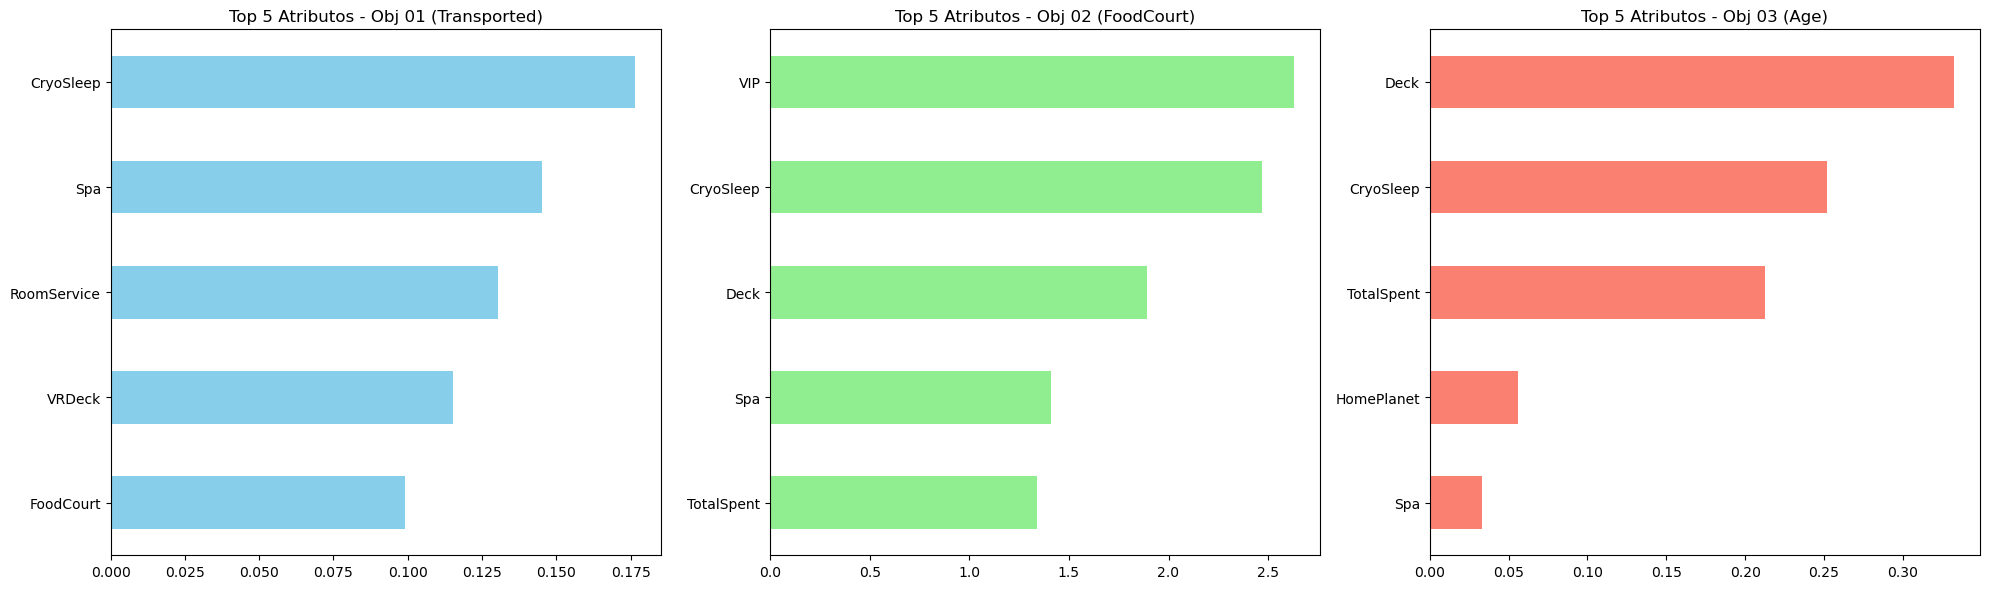

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

modelo_rf_obj1 = grid_rf.best_estimator_
modelo_lin_obj2 = lin_reg
modelo_rf_obj3 = grid_rfr.best_estimator_ 

# Gráfico Obj 1 (Transported)
importances_1 = pd.Series(modelo_rf_obj1.feature_importances_, index=X_1.columns).nlargest(5)
importances_1.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Top 5 Atributos - Obj 01 (Transported)')
axes[0].invert_yaxis()

# Gráfico Obj 2 (FoodCourt) - Regressão Linear
coef_obj2 = pd.Series(
    np.abs(modelo_lin_obj2.coef_),
    index=modelo_lin_obj2.feature_names_in_
).nlargest(5)
coef_obj2.plot(kind='barh', ax=axes[1], color='lightgreen')
axes[1].set_title('Top 5 Atributos - Obj 02 (FoodCourt)')
axes[1].invert_yaxis()

# Gráfico Obj 3 (Age)
importances_3 = pd.Series(modelo_rf_obj3.feature_importances_, index=X_3.columns).nlargest(5)
importances_3.plot(kind='barh', ax=axes[2], color='salmon')
axes[2].set_title('Top 5 Atributos - Obj 03 (Age)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

In [12]:
print(X_3.columns.tolist())

pd.Series(
    grid_rfr.best_estimator_.feature_importances_,
    index=X_3.columns
).sort_values(ascending=False)

['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Deck', 'Side', 'TotalSpent']


Deck            0.332249
CryoSleep       0.251836
TotalSpent      0.212586
HomePlanet      0.056208
Spa             0.033349
ShoppingMall    0.024972
FoodCourt       0.021349
RoomService     0.019485
VRDeck          0.018198
Destination     0.018065
Side            0.009277
VIP             0.002425
dtype: float64

## Discussão e Conclusões

Neste projeto, explorámos os dados dos passageiros do Spaceship Titanic com o objetivo de prever o transporte interdimensional, estimar gastos a bordo e inferir idades. Através da aplicação de modelos de Machine Learning e otimização de hiper-parâmetros (GridSearchCV), retirámos as seguintes conclusões:

1. **Objetivo 1 (Prever Transported):** Os resultados obtidos demonstram que tanto a Regressão Logística como o Random Forest apresentaram o melhor desempenho no conjunto de teste externo, alcançando valores semelhantes de Accuracy e F1-Score. Apesar do XGBoost ser um modelo mais complexo, apresentou menor capacidade de generalização neste problema. A análise da importância dos atributos revelou que o CryoSleep foi uma das variáveis mais relevantes para a previsão da variável Transported. As despesas a bordo, nomeadamente Spa, VRDeck e RoomService, surgiram também entre os atributos mais importantes. Estes resultados fazem sentido do ponto de vista lógico, uma vez que passageiros em sono criogénico tendem a não realizar despesas e apresentam padrões de comportamento bastante distintos dos restantes passageiros.

2. **Objetivo 2 (Prever FoodCourt):** A previsão dos gastos na praça de alimentação demonstrou que a aplicação de uma transformação logarítmica à variável alvo melhorou significativamente o desempenho dos modelos. Após esta transformação, a Regressão Linear apresentou os melhores resultados, obtendo valores de RMSE e MAE semelhantes aos do Random Forest Regressor. A análise dos coeficientes do modelo revelou que atributos como Spa, Age, CryoSleep, VRDeck e VIP foram os mais relevantes para a previsão dos gastos em FoodCourt. Isto sugere que passageiros com maiores despesas em serviços premium da nave e determinadas características de perfil tendem também a apresentar maiores gastos na praça de alimentação.

3. **Objetivo 3 (Prever Idade dos Transportados):** A previsão da idade revelou-se um problema relativamente desafiante. Através dos resultados, foi possível perceber que esta variável não é facilmente inferida a partir da análise dos atributos do dataset. Dos modelos testados, o Random Forest Regressor foi o que apresentou melhores resultados em todas as métricas (MAE, RMSE e R²). No entanto, o valor de R² obtido (~0.18) demonstra uma capacidade preditiva limitada, uma vez que representa apenas uma ligeira melhoria comparativamente a uma previsão baseada na média. A criação da variável **TotalSpent** permitiu uma ligeira melhoria no desempenho dos modelos, o que sugere uma possível relação entre os padrões de consumo e idade. A análise da importância das variáveis demonstrou que os atributos mais relevantes foram: VRDeck, CryoSleep, TotalSpent, HomePlanet e Spa. Importa ainda notar que o TotalSpent corresponde à agregação de todas as categorias com gastos associados. Assim, a sua importância no gráfico deve ser interpretada tendo isso em conta, uma vez que parte da informação já se encontra representada em variáveis individuais, como Spa, o que introduz alguma redundância na análise. No exemplo fornecido, o modelo Decision Tree apresentou resultados ligeiramente melhores do que o Random Forest. Apesar disso, como o conjunto avaliado contém apenas 10 passageiros (sendo somente 5 transportados), esta diferença poderá dever-se ao reduzido tamanho da amostra, mantendo-se o Random Forest como o modelo com melhor desempenho geral.